# Sales Analytics Lab — NumPy First

**Intro to Data Science**  
**Instructor: Masoud Ahangari**

### Class rule

> **Pandas is used only to read the CSV and extract columns. After that, all analysis is done with NumPy.**

The dataset is already cleaned. Today is not about data cleaning or Pandas.

**Flow:**  
`CSV → NumPy Arrays → Statistics → Charts → Business Insights → Dashboard`


## Business Scenario

You are the Data Analytics Team of an online retail company.

The CEO wants answers — not code.

We will answer six questions:

1. How much revenue did the company generate?
2. What does a typical order look like?
3. Are there unusually large orders?
4. What does the order-value distribution look like?
5. Do larger baskets tend to produce larger order values?
6. How does revenue change across months and countries?


## 1. Import the tools

We need only three libraries:

- **Pandas** → only for reading the CSV
- **NumPy** → all numerical analysis
- **Matplotlib** → charts


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Read the CSV, then leave Pandas behind

The notebook is expected to be inside the `notebook/` folder and the CSV inside `data/`.

We immediately convert the columns we need to NumPy arrays.


In [4]:
# Pandas is used only here.
df = pd.read_csv("../data/online_retail_orders_clean.csv")
df

,OrderID,OrderDate,OrderMonth,CustomerID,Country,TotalQuantity,DistinctProducts,LineCount,OrderValueGBP,AvgUnitPriceGBP,MaxUnitPriceGBP
0,536365,2010-12-01,2010-12,17850,United Kingdom,40,7,7,139.12,3.48,7.65
1,536366,2010-12-01,2010-12,17850,United Kingdom,12,2,2,22.20,1.85,1.85
2,536367,2010-12-01,2010-12,13047,United Kingdom,83,12,12,278.73,3.36,9.95
3,536368,2010-12-01,2010-12,13047,United Kingdom,15,4,4,70.05,4.67,4.95
4,536369,2010-12-01,2010-12,13047,United Kingdom,3,1,1,17.85,5.95,5.95
...,...,...,...,...,...,...,...,...,...,...,...
18397,581583,2011-12-09,2011-12,13777,United Kingdom,76,2,2,124.60,1.64,1.85
18398,581584,2011-12-09,2011-12,13777,United Kingdom,120,2,2,140.64,1.17,1.85
18399,581585,2011-12-09,2011-12,15804,United Kingdom,278,21,21,329.05,1.18,5.95
18400,581586,2011-12-09,2011-12,13113,United Kingdom,66,4,4,339.20,5.14,8.95


In [7]:
df["OrderID"].to_numpy()

array([536365, 536366, 536367, ..., 581585, 581586, 581587],
      shape=(18402,))

In [5]:
df.shape

(18402, 11)

In [8]:
order_id = df["OrderID"].to_numpy()
order_month = df["OrderMonth"].to_numpy()
country = df["Country"].to_numpy()
quantity = df["TotalQuantity"].to_numpy()
order_value = df["OrderValueGBP"].to_numpy()

# From this point forward, we do not use the DataFrame.
del df

print("Number of orders:", len(order_value))
print("First 5 order values:", order_value[:5])
print("First 5 quantities:", quantity[:5])

Number of orders: 18402
First 5 order values: [139.12  22.2  278.73  70.05  17.85]
First 5 quantities: [40 12 83 15  3]


---
# Part A — Basic Business Numbers

## 3. Total Revenue and Number of Orders

Before running the cell, predict:

**Which NumPy function should calculate total revenue?**


In [3]:
total_revenue = np.sum(order_value)
number_of_orders = len(order_value)

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Number of Orders: {number_of_orders:,}")

Total Revenue: £8,761,066.65
Number of Orders: 18,402


## 4. What is a “typical” order?

Let's compare **Mean** and **Median**.

If they are very different, that tells us something important about the distribution.


In [4]:
mean_order = np.mean(order_value)
median_order = np.median(order_value)
min_order = np.min(order_value)
max_order = np.max(order_value)

print(f"Mean Order Value:   £{mean_order:,.2f}")
print(f"Median Order Value: £{median_order:,.2f}")
print(f"Minimum Order:      £{min_order:,.2f}")
print(f"Maximum Order:      £{max_order:,.2f}")

Mean Order Value:   £476.09
Median Order Value: £302.22
Minimum Order:      £0.38
Maximum Order:      £168,469.60


### Think

- Is the Mean higher than the Median?
- If yes, what could pull the Mean upward?
- Which number better describes a typical customer order?

This is where **skewness** becomes useful conceptually.


## 5. Variance and Standard Deviation

These describe how spread out order values are.


In [5]:
variance = np.var(order_value)
std_dev = np.std(order_value)

print(f"Variance: {variance:,.2f}")
print(f"Standard Deviation: £{std_dev:,.2f}")

Variance: 2,818,543.88
Standard Deviation: £1,678.85


---
# Part B — Distribution

## 6. Histogram — Full Distribution

First, let's look at all orders.

Do not remove extreme values just because the chart becomes compressed.


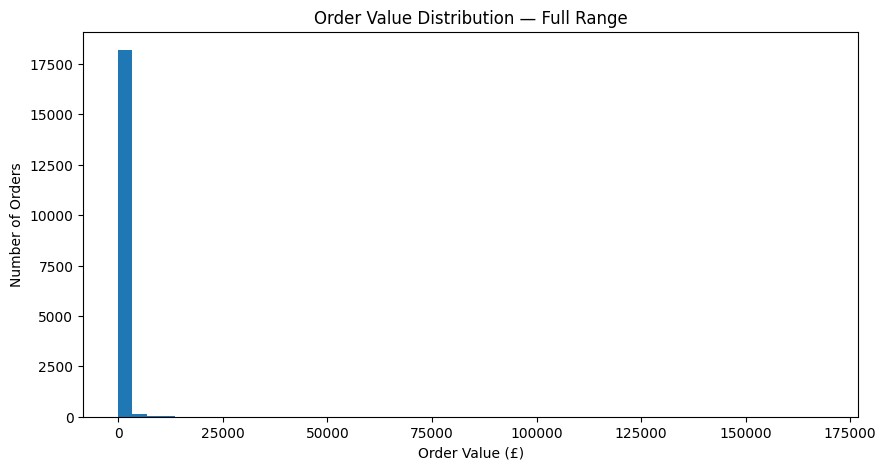

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(order_value, bins=50)
plt.title("Order Value Distribution — Full Range")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")
plt.show()

### What happened?

A small number of very large orders can compress most of the histogram near the left side.

That is not a cleaning problem.

For teaching and readability, we can **zoom the chart** without deleting data.


## 7. Histogram — Main 99%

The 99th percentile is used only as a **visual limit**.

All statistics still use the full dataset.


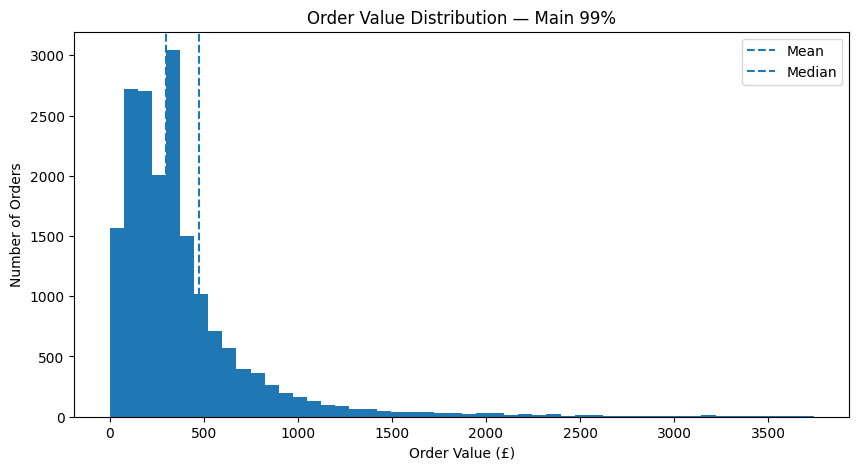

99th Percentile: £3,762.47


In [7]:
p99 = np.percentile(order_value, 99)

main_99_mask = order_value <= p99
main_99_order_value = order_value[main_99_mask]

plt.figure(figsize=(10, 5))
plt.hist(main_99_order_value, bins=50)
plt.axvline(mean_order, linestyle="--", label="Mean")
plt.axvline(median_order, linestyle="--", label="Median")
plt.title("Order Value Distribution — Main 99%")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()

print(f"99th Percentile: £{p99:,.2f}")

### Interpretation

If the distribution has a long tail to the right and:

**Mean > Median**

then the distribution is **right-skewed**.

A relatively small number of large orders pull the Mean upward.


---
# Part C — Quartiles, IQR, and Unusual Orders

## 8. Q1, Q2, Q3


In [8]:
q1 = np.percentile(order_value, 25)
q2 = np.percentile(order_value, 50)
q3 = np.percentile(order_value, 75)

print(f"Q1: £{q1:,.2f}")
print(f"Q2 / Median: £{q2:,.2f}")
print(f"Q3: £{q3:,.2f}")

Q1: £157.78
Q2 / Median: £302.22
Q3: £465.28


## 9. IQR and Outlier Bounds

Recall:

`IQR = Q3 - Q1`

`Lower Bound = Q1 - 1.5 × IQR`

`Upper Bound = Q3 + 1.5 × IQR`


In [9]:
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"IQR: £{iqr:,.2f}")
print(f"Lower Bound: £{lower_bound:,.2f}")
print(f"Upper Bound: £{upper_bound:,.2f}")

IQR: £307.50
Lower Bound: £-303.47
Upper Bound: £926.53


## 10. Boolean Masking — Find High Outliers

This directly connects the IQR rule to NumPy logical indexing.


In [10]:
high_outlier_mask = order_value > upper_bound

high_outliers = order_value[high_outlier_mask]
high_outlier_count = np.sum(high_outlier_mask)
high_outlier_percentage = high_outlier_count / len(order_value) * 100

print("High Outlier Count:", high_outlier_count)
print(f"Percentage of Orders: {high_outlier_percentage:.2f}%")
print("First 10 High Outliers:")
print(high_outliers[:10])

High Outlier Count: 1460
Percentage of Orders: 7.93%
First 10 High Outliers:
[3193.92 1825.74 1024.68 2474.74  950.09 1919.14 1552.98 2558.42 1132.8
 1095.12]


> **Outlier ≠ bad data**

An outlier is statistically unusual.  
It is not automatically an error, fraud, or a value that should be deleted.


## 11. Box Plot


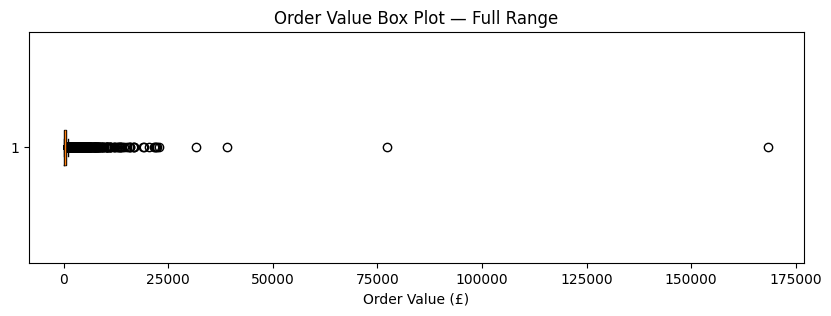

In [11]:
plt.figure(figsize=(10, 3))
plt.boxplot(order_value, vert=False)
plt.title("Order Value Box Plot — Full Range")
plt.xlabel("Order Value (£)")
plt.show()

The full-range box plot is compressed by very large orders.

Again, we can zoom visually without deleting observations.


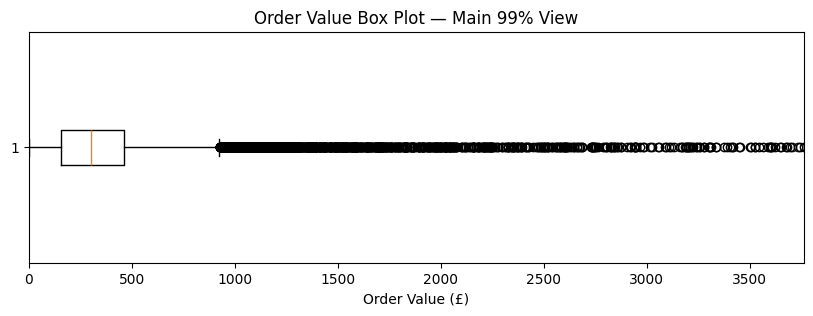

In [12]:
plt.figure(figsize=(10, 3))
plt.boxplot(order_value, vert=False)
plt.xlim(0, p99)
plt.title("Order Value Box Plot — Main 99% View")
plt.xlabel("Order Value (£)")
plt.show()

---
# Part D — Percentiles and Segmentation

## 12. Top 10% of Orders

Let's use the 90th percentile to create a business segment.


In [13]:
p90 = np.percentile(order_value, 90)

top_10_mask = order_value >= p90
top_10_orders = order_value[top_10_mask]

print(f"90th Percentile: £{p90:,.2f}")
print("Number of Orders in Top 10%:", np.sum(top_10_mask))
print(f"Revenue from Top 10% Orders: £{np.sum(top_10_orders):,.2f}")

90th Percentile: £812.02
Number of Orders in Top 10%: 1841
Revenue from Top 10% Orders: £3,958,747.10


---
# Part E — Covariance

## 13. Quantity vs Order Value

Before running the code:

**Do you expect the covariance to be positive, negative, or near zero?**


In [14]:
covariance_matrix = np.cov(quantity, order_value)
covariance = covariance_matrix[0, 1]

print(f"Covariance: {covariance:,.2f}")

if covariance > 0:
    print("Direction: Positive")
elif covariance < 0:
    print("Direction: Negative")
else:
    print("Direction: Near zero")

Covariance: 1,488,804.23
Direction: Positive


> Positive covariance means the two variables tend to move in the same direction.

> **Covariance does not prove causation.**


## 14. Scatter Plot — Main 99% View

We use a visual mask so a few extreme values do not compress the graph.


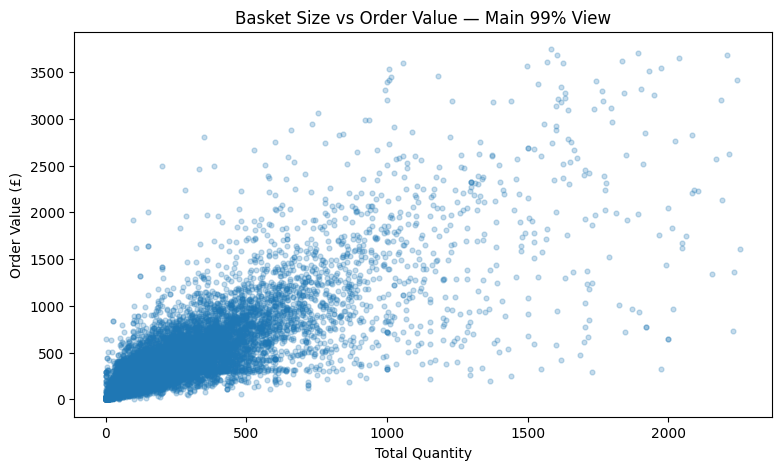

In [15]:
quantity_p99 = np.percentile(quantity, 99)

scatter_mask = (quantity <= quantity_p99) & (order_value <= p99)

plt.figure(figsize=(9, 5))
plt.scatter(
    quantity[scatter_mask],
    order_value[scatter_mask],
    alpha=0.25,
    s=12
)
plt.title("Basket Size vs Order Value — Main 99% View")
plt.xlabel("Total Quantity")
plt.ylabel("Order Value (£)")
plt.show()

---
# Part F — Management View with NumPy

We are still not using Pandas.

For these final views, we need two small NumPy ideas:

- `np.unique(...)` → get unique months/countries
- Boolean masks → select rows belonging to each month/country

The goal is still the same NumPy thinking you already know.


## 15. Monthly Revenue


In [16]:
months = np.unique(order_month)

monthly_revenue = np.array([
    np.sum(order_value[order_month == month])
    for month in months
])

print("Months:", months)
print("Monthly Revenue:", monthly_revenue)

Months: ['2010-12' '2011-01' '2011-02' '2011-03' '2011-04' '2011-05' '2011-06'
 '2011-07' '2011-08' '2011-09' '2011-10' '2011-11' '2011-12']
Monthly Revenue: [ 567490.72  564026.64  443346.02  584562.85  455266.91  660481.9
  654432.56  592731.9   636807.24  940900.81 1005642.9  1142145.77
  513230.43]


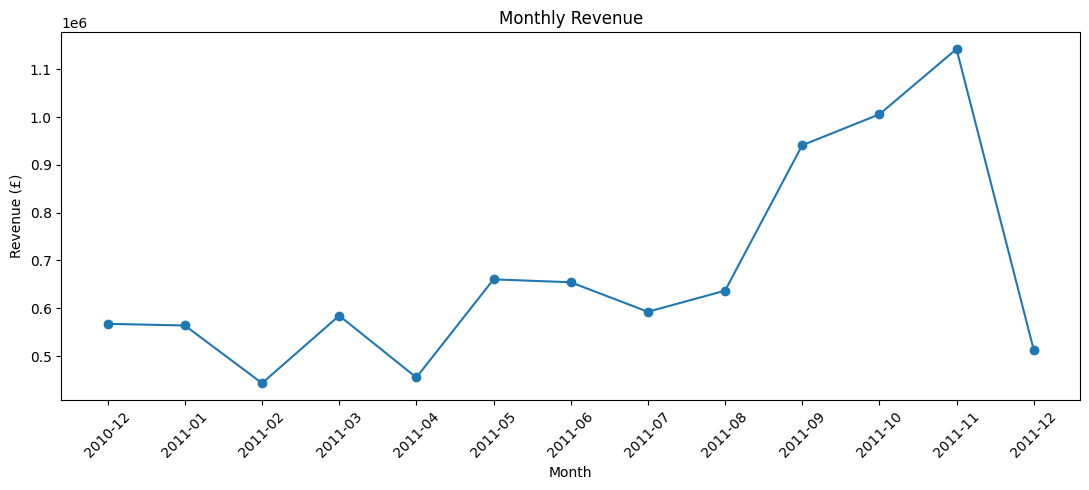

Strongest Month: 2011-11
Revenue: £1,142,145.77


In [17]:
plt.figure(figsize=(11, 5))
plt.plot(months, monthly_revenue, marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

strongest_month_index = np.argmax(monthly_revenue)

print("Strongest Month:", months[strongest_month_index])
print(f"Revenue: £{monthly_revenue[strongest_month_index]:,.2f}")

## 16. Top 10 Countries by Revenue

Same idea:

1. Get unique countries.
2. Build a Boolean mask for each country.
3. Sum the order values.
4. Sort the totals.


In [18]:
countries = np.unique(country)

country_revenue = np.array([
    np.sum(order_value[country == c])
    for c in countries
])

top_10_indices = np.argsort(country_revenue)[::-1][:10]

top_10_countries = countries[top_10_indices]
top_10_revenue = country_revenue[top_10_indices]

for c, revenue in zip(top_10_countries, top_10_revenue):
    print(f"{c:20s} £{revenue:,.2f}")

United Kingdom       £7,265,862.23
Netherlands          £283,889.34
EIRE                 £257,296.56
Germany              £205,569.89
France               £183,891.68
Australia            £138,171.31
Spain                £55,725.11
Switzerland          £52,441.95
Japan                £37,416.37
Belgium              £36,927.34


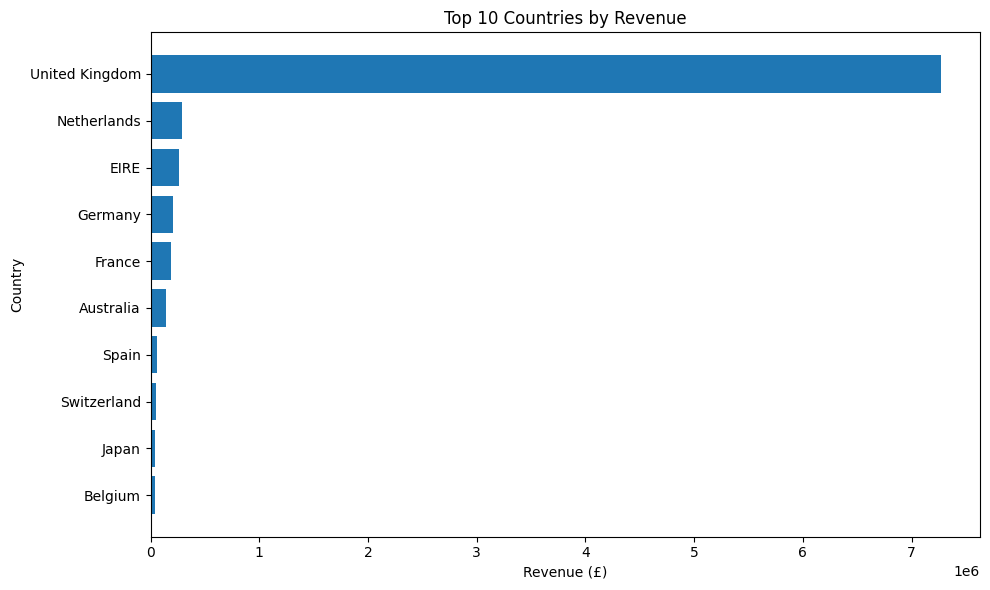

In [19]:
plt.figure(figsize=(10, 6))
plt.barh(top_10_countries[::-1], top_10_revenue[::-1])
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

---
# Final Business Summary

At this point, we have moved from simple NumPy arrays to business insight.

We did **not** need Pandas for the analysis.

Our path was:

`NumPy Array → Statistic → Mask → Visualization → Interpretation`


In [20]:
print("SALES ANALYTICS SUMMARY")
print("-" * 45)
print(f"Total Revenue:        £{total_revenue:,.2f}")
print(f"Orders:               {number_of_orders:,}")
print(f"Mean Order Value:     £{mean_order:,.2f}")
print(f"Median Order Value:   £{median_order:,.2f}")
print(f"Q1 / Q3:              £{q1:,.2f} / £{q3:,.2f}")
print(f"IQR:                  £{iqr:,.2f}")
print(f"Upper IQR Bound:      £{upper_bound:,.2f}")
print(f"High Outliers:        {high_outlier_count:,} ({high_outlier_percentage:.2f}%)")
print(f"Strongest Month:      {months[strongest_month_index]}")
print(f"Top Country:          {top_10_countries[0]}")
print(f"Covariance Direction: {'Positive' if covariance > 0 else 'Negative' if covariance < 0 else 'Near zero'}")

SALES ANALYTICS SUMMARY
---------------------------------------------
Total Revenue:        £8,761,066.65
Orders:               18,402
Mean Order Value:     £476.09
Median Order Value:   £302.22
Q1 / Q3:              £157.78 / £465.28
IQR:                  £307.50
Upper IQR Bound:      £926.53
High Outliers:        1,460 (7.93%)
Strongest Month:      2011-11
Top Country:          United Kingdom
Covariance Direction: Positive


# CEO Challenge — 60 Seconds

Imagine the CEO is standing in front of you.

Explain the business using the results above.

### Rule

Do **not** say:

- NumPy
- Python
- array
- function
- code

Talk only about the business.

---

### Key idea

**Data → Statistic → Visualization → Interpretation → Business Decision → Dashboard**

Next, we will use **Cursor as our software engineer** to turn this analysis into a Streamlit dashboard.
